# Notebook 4 - Evaluation et modele hybride

Objectif : comparer les approches (popularite, cold start, content-based, collaborative filtering) et construire le modele hybride final.


## Metriques utilisees

Deux metriques principales pour evaluer la qualite des recommandations sur une liste de 5 articles :

**Hit Ratio** : proportion d'utilisateurs pour lesquels le vrai article lu se trouve dans la liste de 5 recommandations. Un hit ratio de 0.25 signifie que dans 25% des cas, le bon article est dans le top 5.

**Mean Reciprocal Rank** : quand le bon article est dans la liste, a quel rang est-il ? Un MRR de 1.0 signifierait qu'il est toujours en premiere position. Un MRR de 0.20 signifie qu'en moyenne il est autour du rang 5.

**Couverture** : nombre d'articles distincts recommandes au total sur l'ensemble des utilisateurs evalues. Une couverture faible (ex: 28) signifie que le modele recommande toujours les memes articles. Une couverture elevee (ex: 10 000) montre une bonne diversite.


## 1. Chargement


In [1]:
import pandas as pd
import numpy as np
import os
import json
import time
import joblib
import matplotlib.pyplot as plt
from sklearn.preprocessing import normalize
from scipy.sparse import csr_matrix, load_npz

DATA_RAW = "../data/raw/"
DATA_PROC = "../data/processed/"
OUT = "../out/"
CB_DIR = os.path.join(OUT, "models", "content_based")
CF_DIR = os.path.join(OUT, "models", "collaborative")
CFG_DIR = os.path.join(OUT, "models", "config")
FIG = os.path.join(OUT, "figures")
os.makedirs(FIG, exist_ok=True)

articles = pd.read_csv(os.path.join(DATA_RAW, "articles_metadata.csv"))
clicks = pd.read_parquet(os.path.join(DATA_PROC, "clicks_enriched.parquet"))

### 1.1 Modele content-based


In [2]:
embeddings_cb = np.load(os.path.join(CB_DIR, "embeddings_reduced.npy"))
embeddings_cb = normalize(embeddings_cb, norm="l2", axis=1)

with open(os.path.join(CB_DIR, "user_articles.json"), "r") as f:
    user_articles_full = json.load(f)

pop_df = pd.read_parquet(os.path.join(CB_DIR, "article_popularity.parquet"))
article_popularity = pop_df.sort_values("nb_clicks", ascending=False).index.tolist()

cold_start_df = pd.read_parquet(os.path.join(CB_DIR, "cold_start_ranking.parquet"))
cold_start_ranking = cold_start_df.sort_values("cold_start_score", ascending=False)

print(f"Embeddings : {embeddings_cb.shape}")
print(f"Users : {len(user_articles_full):,}")

Embeddings : (364047, 50)
Users : 322,897


### 1.2 Modele collaboratif ALS


In [3]:
als_model = joblib.load(os.path.join(CF_DIR, "als_model.joblib"))

with open(os.path.join(CF_DIR, "user_map.json"), "r") as f:
    user_map = {int(k): v for k, v in json.load(f).items()}
with open(os.path.join(CF_DIR, "article_map.json"), "r") as f:
    article_map = {int(k): v for k, v in json.load(f).items()}
with open(os.path.join(CF_DIR, "article_map_inv.json"), "r") as f:
    article_map_inv = json.load(f)

print(f"ALS user factors : {als_model.user_factors.shape}")
print(f"ALS item factors : {als_model.item_factors.shape}")

ALS user factors : (322897, 50)
ALS item factors : (46033, 50)


## 2. Construction du jeu de test

Pour evaluer correctement, on retire le dernier clic de chaque utilisateur. Les modeles doivent predire ce dernier clic sans l'avoir vu dans l'historique.


In [4]:
# Split temporel : dernier clic = test
clicks_sorted = clicks.sort_values(["user_id", "click_timestamp"])
last_clicks = clicks_sorted.groupby("user_id").tail(1)
train_clicks = clicks_sorted.drop(last_clicks.index)

# Ground truth
test_ground_truth = dict(zip(last_clicks["user_id"], last_clicks["click_article_id"]))

# Historique TRAIN (sans le dernier clic)
user_articles_train = {}
for uid, group in train_clicks.groupby("user_id"):
    user_articles_train[str(uid)] = group["click_article_id"].tolist()

# Matrice TRAIN pour le collaborative filtering
train_interactions = train_clicks.groupby(["user_id", "click_article_id"]).size().reset_index(name="nb_clicks")
mask = train_interactions["user_id"].isin(user_map.keys()) & train_interactions["click_article_id"].isin(article_map.keys())
rows_t = train_interactions.loc[mask, "user_id"].map(user_map).astype(int).values
cols_t = train_interactions.loc[mask, "click_article_id"].map(article_map).astype(int).values
data_t = train_interactions.loc[mask, "nb_clicks"].values.astype(np.float32)

n_users = len(user_map)
n_items = len(article_map)
user_item_train = csr_matrix((data_t, (rows_t, cols_t)), shape=(n_users, n_items))

# Echantillon evaluation
eval_size = 5000
eval_users = list(test_ground_truth.keys())[:eval_size]
eval_sample = {uid: test_ground_truth[uid] for uid in eval_users}

print(f"Train : {len(train_clicks):,} interactions")
print(f"Test : {len(test_ground_truth):,} users")
print(f"Echantillon evaluation : {eval_size}")

Train : 2,665,284 interactions
Test : 322,897 users
Echantillon evaluation : 5000


## 3. Fonctions de recommandation

Chaque fonction utilise l'historique train (sans le dernier clic) pour ne pas tricher.


In [5]:
# Popularite pure (baseline)
def recommend_popularity(user_id, top_n=5):
    read = set(user_articles_train.get(str(user_id), []))
    return [{"article_id": a, "score": 0.0} for a in article_popularity if a not in read][:top_n]

# Cold start : recence + popularite
def recommend_cold_start(user_id, top_n=5):
    read = set(user_articles_train.get(str(user_id), []))
    recs = []
    for _, row in cold_start_ranking.iterrows():
        aid = int(row["article_id"])
        if aid not in read:
            recs.append({"article_id": aid, "score": round(float(row["cold_start_score"]), 4)})
        if len(recs) >= top_n:
            break
    return recs

# Content-based (cosinus sur embeddings)
def recommend_cb(user_id, top_n=5):
    article_ids = user_articles_train.get(str(user_id), [])
    if not article_ids:
        return recommend_cold_start(user_id, top_n)
    valid_ids = [a for a in article_ids if a < len(embeddings_cb)]
    if not valid_ids:
        return recommend_cold_start(user_id, top_n)
    profile = embeddings_cb[valid_ids].mean(axis=0)
    norm = np.linalg.norm(profile)
    if norm > 0:
        profile = profile / norm
    scores = embeddings_cb.dot(profile)
    read = set(article_ids)
    ranked = np.argsort(scores)[::-1]
    recs = []
    for idx in ranked:
        if int(idx) not in read:
            recs.append({"article_id": int(idx), "score": float(scores[idx])})
        if len(recs) >= top_n:
            break
    return recs

# Collaborative filtering (ALS)
def recommend_cf(user_id, top_n=5):
    uid_mapped = user_map.get(int(user_id))
    if uid_mapped is None:
        return recommend_cold_start(user_id, top_n)
    rec_ids, rec_scores = als_model.recommend(
        uid_mapped, user_item_train[uid_mapped], N=top_n, filter_already_liked_items=True
    )
    recs = []
    for idx, score in zip(rec_ids, rec_scores):
        aid = article_map_inv.get(str(int(idx)))
        if aid is not None:
            recs.append({"article_id": aid, "score": float(score)})
    return recs

print("Fonctions definies : popularite, cold start, content-based, collaborative")

Fonctions definies : popularite, cold start, content-based, collaborative


## 4. Evaluation


In [6]:
def evaluate_model(recommend_fn, test_data, top_n=5):
    hits = 0
    reciprocal_ranks = []
    all_recommended = set()
    total = 0
    
    for uid, true_article in test_data.items():
        recs = recommend_fn(uid, top_n=top_n)
        if not recs:
            continue
        
        total += 1
        rec_ids = [r["article_id"] for r in recs]
        all_recommended.update(rec_ids)
        
        if true_article in rec_ids:
            hits += 1
            rank = rec_ids.index(true_article) + 1
            reciprocal_ranks.append(1.0 / rank)
        else:
            reciprocal_ranks.append(0.0)
    
    hit_ratio = hits / total if total > 0 else 0
    mean_reciprocal_rank = np.mean(reciprocal_ranks) if reciprocal_ranks else 0
    coverage = len(all_recommended)
    
    return {
        "hit_ratio": round(hit_ratio, 4),
        "mean_reciprocal_rank": round(mean_reciprocal_rank, 4),
        "couverture": coverage,
        "nb_evalues": total
    }

In [7]:
print(f"Evaluation sur {eval_size} users (liste de 5 recommandations)\n")

print("1/4 Popularite pure...")
t0 = time.time()
eval_pop = evaluate_model(recommend_popularity, eval_sample, top_n=5)
print(f"    Hit Ratio = {eval_pop['hit_ratio']:.4f} | Mean Reciprocal Rank = {eval_pop['mean_reciprocal_rank']:.4f} | {time.time()-t0:.0f}s")

print("2/4 Cold Start (recence + popularite)...")
t0 = time.time()
eval_cs = evaluate_model(recommend_cold_start, eval_sample, top_n=5)
print(f"    Hit Ratio = {eval_cs['hit_ratio']:.4f} | Mean Reciprocal Rank = {eval_cs['mean_reciprocal_rank']:.4f} | {time.time()-t0:.0f}s")

print("3/4 Content-Based (cosinus)...")
t0 = time.time()
eval_cb = evaluate_model(recommend_cb, eval_sample, top_n=5)
print(f"    Hit Ratio = {eval_cb['hit_ratio']:.4f} | Mean Reciprocal Rank = {eval_cb['mean_reciprocal_rank']:.4f} | {time.time()-t0:.0f}s")

print("4/4 Collaborative Filtering (ALS)...")
t0 = time.time()
eval_cf = evaluate_model(recommend_cf, eval_sample, top_n=5)
print(f"    Hit Ratio = {eval_cf['hit_ratio']:.4f} | Mean Reciprocal Rank = {eval_cf['mean_reciprocal_rank']:.4f} | {time.time()-t0:.0f}s")

comparison = pd.DataFrame([
    {"Modele": "Popularite pure", **eval_pop},
    {"Modele": "Cold Start (recence + popularite)", **eval_cs},
    {"Modele": "Content-Based (cosinus)", **eval_cb},
    {"Modele": "Collaborative Filtering (ALS)", **eval_cf},
])
print()
print(comparison.to_string(index=False))

Evaluation sur 5000 users (liste de 5 recommandations)

1/4 Popularite pure...
    Hit Ratio = 0.0170 | Mean Reciprocal Rank = 0.0061 | 31s
2/4 Cold Start (recence + popularite)...
    Hit Ratio = 0.0170 | Mean Reciprocal Rank = 0.0061 | 7s
3/4 Content-Based (cosinus)...
    Hit Ratio = 0.0026 | Mean Reciprocal Rank = 0.0018 | 90s
4/4 Collaborative Filtering (ALS)...
    Hit Ratio = 0.2628 | Mean Reciprocal Rank = 0.2086 | 2s

                           Modele  hit_ratio  mean_reciprocal_rank  couverture  nb_evalues
                  Popularite pure     0.0170                0.0061          28        5000
Cold Start (recence + popularite)     0.0170                0.0061          28        5000
          Content-Based (cosinus)     0.0026                0.0018       10194        5000
    Collaborative Filtering (ALS)     0.2628                0.2086         206        5000


## 5. Coherence categorielle

Les categories des articles recommandes correspondent-elles aux categories lues par l'utilisateur ?


In [8]:
def category_overlap(recommend_fn, sample_users, top_n=5):
    overlaps = []
    for uid in sample_users:
        recs = recommend_fn(uid, top_n=top_n)
        if not recs:
            continue
        read_ids = user_articles_train.get(str(uid), [])
        read_cats = set(articles[articles["article_id"].isin(read_ids)]["category_id"])
        rec_ids = [r["article_id"] for r in recs]
        rec_cats = set(articles[articles["article_id"].isin(rec_ids)]["category_id"])
        if rec_cats:
            overlaps.append(len(read_cats & rec_cats) / len(rec_cats))
    return np.mean(overlaps) if overlaps else 0

sample_uids = eval_users[:2000]

cat_pop = category_overlap(recommend_popularity, sample_uids)
cat_cs = category_overlap(recommend_cold_start, sample_uids)
cat_cb = category_overlap(recommend_cb, sample_uids)
cat_cf = category_overlap(recommend_cf, sample_uids)

print("Coherence categorielle (0 = aucune, 1 = parfaite) :")
print(f"  Popularite pure              : {cat_pop:.1%}")
print(f"  Cold Start (recence + pop)   : {cat_cs:.1%}")
print(f"  Content-Based (cosinus)      : {cat_cb:.1%}")
print(f"  Collaborative Filtering (ALS): {cat_cf:.1%}")

Coherence categorielle (0 = aucune, 1 = parfaite) :
  Popularite pure              : 42.1%
  Cold Start (recence + pop)   : 42.1%
  Content-Based (cosinus)      : 69.4%
  Collaborative Filtering (ALS): 38.2%


## 6. Modele hybride

On combine content-based et collaborative filtering avec un poids alpha.

Score hybride = alpha _ score_collaborative_normalise + (1 - alpha) _ score_content_based_normalise

alpha = 1 : 100% collaborative. alpha = 0 : 100% content-based.


In [9]:
def recommend_hybrid(user_id, alpha=0.6, top_n=5):
    cb_recs = recommend_cb(user_id, top_n=50)
    cf_recs = recommend_cf(user_id, top_n=50)
    
    if not cf_recs and not cb_recs:
        return recommend_cold_start(user_id, top_n)
    if not cf_recs:
        return cb_recs[:top_n]
    if not cb_recs:
        return cf_recs[:top_n]
    
    cb_scores = {r["article_id"]: r["score"] for r in cb_recs}
    cf_scores = {r["article_id"]: r["score"] for r in cf_recs}
    
    cb_min, cb_max = min(cb_scores.values()), max(cb_scores.values())
    cf_min, cf_max = min(cf_scores.values()), max(cf_scores.values())
    cb_range = (cb_max - cb_min) or 1
    cf_range = (cf_max - cf_min) or 1
    
    all_articles = set(cb_scores.keys()) | set(cf_scores.keys())
    hybrid = {}
    for aid in all_articles:
        cb_n = (cb_scores.get(aid, cb_min) - cb_min) / cb_range
        cf_n = (cf_scores.get(aid, cf_min) - cf_min) / cf_range
        hybrid[aid] = alpha * cf_n + (1 - alpha) * cb_n
    
    sorted_recs = sorted(hybrid.items(), key=lambda x: x[1], reverse=True)[:top_n]
    return [{"article_id": aid, "score": round(s, 4)} for aid, s in sorted_recs]

### 6.1 Recherche du meilleur alpha


In [10]:
alpha_eval = {k: v for k, v in list(eval_sample.items())[:2000]}

alphas = [0.0, 0.2, 0.4, 0.5, 0.6, 0.7, 0.8, 1.0]
alpha_results = []

for a in alphas:
    result = evaluate_model(
        lambda uid, top_n=5, _a=a: recommend_hybrid(uid, alpha=_a, top_n=top_n),
        alpha_eval, top_n=5
    )
    alpha_results.append({"alpha": a, **result})
    print(f"alpha = {a:.1f} -> Hit Ratio = {result['hit_ratio']:.4f} | Mean Reciprocal Rank = {result['mean_reciprocal_rank']:.4f} | Couverture = {result['couverture']}")

alpha_df = pd.DataFrame(alpha_results)

alpha = 0.0 -> Hit Ratio = 0.0035 | Mean Reciprocal Rank = 0.0026 | Couverture = 5343
alpha = 0.2 -> Hit Ratio = 0.0035 | Mean Reciprocal Rank = 0.0028 | Couverture = 5340
alpha = 0.4 -> Hit Ratio = 0.0990 | Mean Reciprocal Rank = 0.0307 | Couverture = 4779
alpha = 0.5 -> Hit Ratio = 0.1900 | Mean Reciprocal Rank = 0.1315 | Couverture = 3783
alpha = 0.6 -> Hit Ratio = 0.2020 | Mean Reciprocal Rank = 0.1828 | Couverture = 2867
alpha = 0.7 -> Hit Ratio = 0.2180 | Mean Reciprocal Rank = 0.1876 | Couverture = 1699
alpha = 0.8 -> Hit Ratio = 0.2405 | Mean Reciprocal Rank = 0.1934 | Couverture = 745
alpha = 1.0 -> Hit Ratio = 0.2420 | Mean Reciprocal Rank = 0.1938 | Couverture = 195


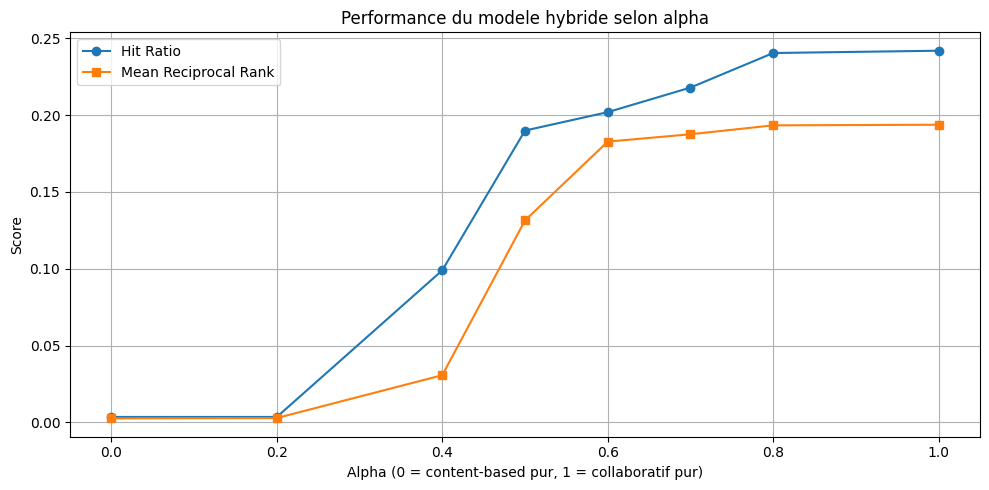

Meilleur alpha : 1.0


In [11]:
plt.figure(figsize=(10, 5))
plt.plot(alpha_df["alpha"], alpha_df["hit_ratio"], marker="o", label="Hit Ratio")
plt.plot(alpha_df["alpha"], alpha_df["mean_reciprocal_rank"], marker="s", label="Mean Reciprocal Rank")
plt.xlabel("Alpha (0 = content-based pur, 1 = collaboratif pur)")
plt.ylabel("Score")
plt.title("Performance du modele hybride selon alpha")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(FIG, "hybrid_alpha_search.png"), dpi=150, bbox_inches="tight")
plt.show()

best_alpha = alpha_df.loc[alpha_df["hit_ratio"].idxmax(), "alpha"]
print(f"Meilleur alpha : {best_alpha}")

### 6.2 Evaluation finale


In [12]:
BEST_ALPHA = best_alpha

eval_hybrid = evaluate_model(
    lambda uid, top_n=5: recommend_hybrid(uid, alpha=BEST_ALPHA, top_n=top_n),
    eval_sample, top_n=5
)
cat_hybrid = category_overlap(
    lambda uid, top_n=5: recommend_hybrid(uid, alpha=BEST_ALPHA, top_n=top_n),
    sample_uids
)

final = pd.DataFrame([
    {"Modele": "Popularite pure",               "Hit Ratio": eval_pop["hit_ratio"], "Mean Reciprocal Rank": eval_pop["mean_reciprocal_rank"], "Couverture": eval_pop["couverture"], "Coherence categorielle": f"{cat_pop:.0%}"},
    {"Modele": "Cold Start (recence + pop)",     "Hit Ratio": eval_cs["hit_ratio"],  "Mean Reciprocal Rank": eval_cs["mean_reciprocal_rank"],  "Couverture": eval_cs["couverture"],  "Coherence categorielle": f"{cat_cs:.0%}"},
    {"Modele": "Content-Based (cosinus)",        "Hit Ratio": eval_cb["hit_ratio"],  "Mean Reciprocal Rank": eval_cb["mean_reciprocal_rank"],  "Couverture": eval_cb["couverture"],  "Coherence categorielle": f"{cat_cb:.0%}"},
    {"Modele": "Collaborative Filtering (ALS)",  "Hit Ratio": eval_cf["hit_ratio"],  "Mean Reciprocal Rank": eval_cf["mean_reciprocal_rank"],  "Couverture": eval_cf["couverture"],  "Coherence categorielle": f"{cat_cf:.0%}"},
    {"Modele": f"Hybride (alpha = {BEST_ALPHA})","Hit Ratio": eval_hybrid["hit_ratio"],"Mean Reciprocal Rank": eval_hybrid["mean_reciprocal_rank"],"Couverture": eval_hybrid["couverture"],"Coherence categorielle": f"{cat_hybrid:.0%}"},
])
print(final.to_string(index=False))

                       Modele  Hit Ratio  Mean Reciprocal Rank  Couverture Coherence categorielle
              Popularite pure     0.0170                0.0061          28                    42%
   Cold Start (recence + pop)     0.0170                0.0061          28                    42%
      Content-Based (cosinus)     0.0026                0.0018       10194                    69%
Collaborative Filtering (ALS)     0.2628                0.2086         206                    38%
        Hybride (alpha = 1.0)     0.2628                0.2086         206                    38%


## 7. Exemples de recommandations


In [13]:
for uid in [0, 1, 100, 1000]:
    recs = recommend_hybrid(uid, alpha=BEST_ALPHA, top_n=5)
    read_ids = user_articles_train.get(str(uid), [])
    read_cats = articles[articles["article_id"].isin(read_ids)]["category_id"].value_counts().head(3)
    
    print(f"User {uid} | Articles lus (train) : {len(read_ids)} | Top categories : {dict(read_cats)}")
    for r in recs:
        meta = articles[articles["article_id"] == r["article_id"]]
        cat = meta["category_id"].values[0] if len(meta) > 0 else "?"
        wc = meta["words_count"].values[0] if len(meta) > 0 else "?"
        print(f"  -> article_id={r['article_id']:>6d} | score={r['score']:.4f} | categorie={cat} | mots={wc}")
    print()

User 0 | Articles lus (train) : 7 | Top categories : {281: np.int64(2), 136: np.int64(1), 186: np.int64(1)}
  -> article_id=293114 | score=1.0000 | categorie=421 | mots=213
  -> article_id=284985 | score=0.8028 | categorie=412 | mots=184
  -> article_id=272218 | score=0.4610 | categorie=399 | mots=238
  -> article_id=160940 | score=0.3487 | categorie=281 | mots=275
  -> article_id=124749 | score=0.3432 | categorie=250 | mots=192

User 1 | Articles lus (train) : 11 | Top categories : {281: np.int64(2), 412: np.int64(2), 43: np.int64(1)}
  -> article_id=284463 | score=1.0000 | categorie=412 | mots=195
  -> article_id=207122 | score=0.9796 | categorie=331 | mots=1044
  -> article_id=119592 | score=0.3095 | categorie=247 | mots=239
  -> article_id=293301 | score=0.2391 | categorie=421 | mots=180
  -> article_id=336430 | score=0.2046 | categorie=437 | mots=167

User 100 | Articles lus (train) : 9 | Top categories : {436: np.int64(3), 250: np.int64(2), 230: np.int64(1)}
  -> article_id=27697

## 8. Sauvegarde du choix final


In [14]:
cfg_path = os.path.join(CFG_DIR, "model_config.json")
with open(cfg_path, "r") as f:
    config = json.load(f)

config["best_alpha"] = float(BEST_ALPHA)
config["pca_components"] = int(embeddings_cb.shape[1])
config["eval_hit_ratio"] = float(eval_hybrid["hit_ratio"])
config["eval_mean_reciprocal_rank"] = float(eval_hybrid["mean_reciprocal_rank"])

with open(cfg_path, "w") as f:
    json.dump(config, f, indent=2)

print(f"Configuration sauvegardee : {json.dumps(config, indent=2)}")

Configuration sauvegardee : {
  "als_factors": 50,
  "als_regularization": 0.01,
  "als_iterations": 15,
  "n_users": 322897,
  "n_items": 46033,
  "best_alpha": 1.0,
  "pca_components": 50,
  "eval_hit_ratio": 0.2628,
  "eval_mean_reciprocal_rank": 0.2086
}
